# Model with conditional interaction

- Author: [givasile](https://givasile.github.io/)
- Runtime: ~5 s
- Description: Global effects (PDP, ALE, RHALE) on a model with a
  conditional interaction; each estimate is compared — and tested — against
  its analytical formula from `effector.benchmarks`.
- 📄 The whole notebook in one page: [PDP report](https://xai-effector.github.io/static/reports/05_conditional_interaction_independent_uniform_global_pdp.html)

In this example, we show global effects of a model with conditional interactions using PDP, ALE, and RHALE.
In particular, we:

1. show how to use `effector` to estimate the global effects using PDP, ALE, and RHALE
2. provide the analytical formulas for the global effects
3. test that (1) and (2) match

We will use the following model: 

$$ 
f(x_1, x_2, x_3) = -x_1^2 \mathbb{1}_{x_2 <0} + x_1^2 \mathbb{1}_{x_2 \geq 0} + e^{x_3} 
$$

where the features $x_1, x_2, x_3$ are independent and uniformly distributed in the interval $[-1, 1]$.


The model has an _interaction_ between $x_1$ and $x_2$ caused by the terms: 
$f_{1,2}(x_1, x_2) = -x_1^2 \mathbb{1}_{x_2 <0} + x_1^2 \mathbb{1}_{x_2 \geq 0}$.
This means that the effect of $x_1$ on the output $y$ depends on the value of $x_2$ and vice versa.
Therefore, there is no golden standard on how to split the effect of $f_{1,2}$ to two parts, one that corresponds to $x_1$ and one to $x_2$.
Each global effect method has a different strategy to handle this issue.
Below we will see how PDP, ALE, and RHALE handle this interaction.

In contrast, $x_3$ does not interact with any other feature, so its effect can be easily computed as $e^{x_3}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import effector

np.random.seed(21)

bench = effector.benchmarks.ConditionalInteractionUniform()
model = bench.model
dataset = bench.dataset
x = bench.generate_data(1000)

## PDP

### Effector

Let's see below the PDP effects for each feature, using `effector`.

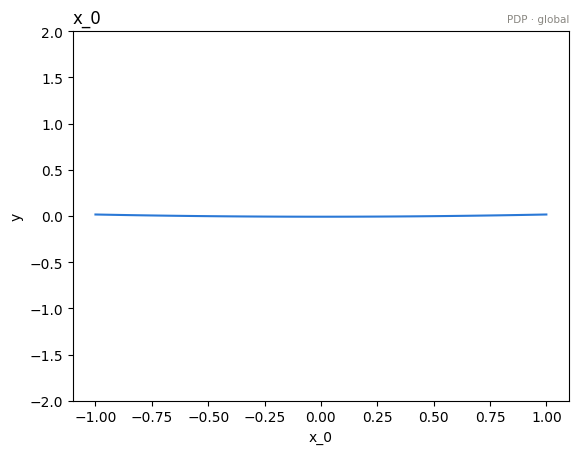

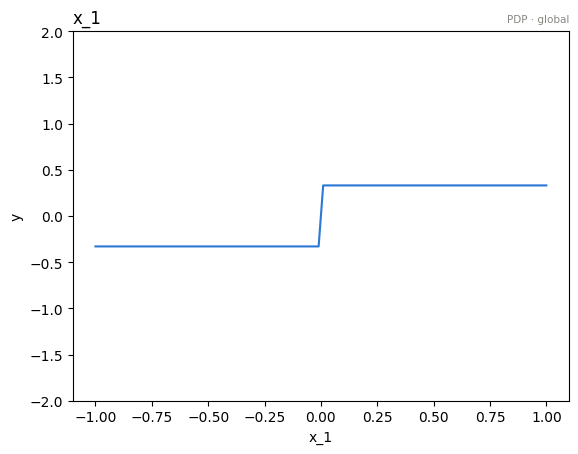

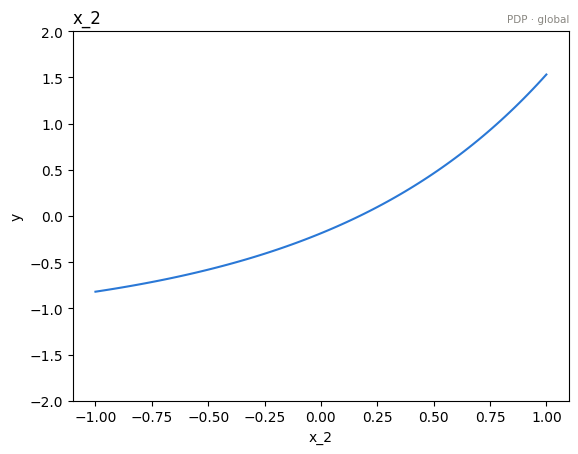

In [2]:
pdp = effector.PDP(x, model.predict, axis_limits=dataset.axis_limits)
pdp.fit(features="all", centering=True)
for feature in [0, 1, 2]:
    pdp.plot(feature=feature, centering=True, y_limits=[-2, 2], heterogeneity=False)

PDP states that:

* $x_1$ has a zero average effect on the model output
* $x_2$ has a constant effect when $x_2 <0$ or $x_2 >0$, but when moving from $x_2^-$ to $x_2^+$ it adds (on average) $+\frac{2}{3}$ units to $y$
* $x_3$ has an effect of $e^{x_3}$

### Derivations

How PDP leads to these explanations? Are they meaningfull? Let's have some analytical derivations.
If you don't care about the derivations, skip the following three cells and go directly to the coclusions.

For $x_1$:

\begin{align}
PDP(x_1) &\propto \frac{1}{N} \sum_{i=1}^{n} f(x_1, \mathbf{x}^i_{/1}) \\
&\propto \frac{1}{N} \sum_{i=1}^{N} -x_1^2 \mathbb{1}_{x_2^i <0} + x_1^2 \mathbb{1}_{x_2^i \geq 0} + e^{x_3^i} \\
&\propto x_1^2 \frac{1}{N}\sum_{i=1}^{n} ( - \mathbb{1}_{x_2^i < 0} + \mathbb{1}_{x_2^i \geq 0}) \\
&\approx c
\end{align}

For $x_2$:

\begin{align}
PDP(x_2) &\propto \frac{1}{N} \sum_{i=1}^{n} f(x_2, \mathbf{x}_{/2}^i) \\
&\propto \frac{1}{N} \sum_{i=1}^{n} \left [ (-x_1^i)^2 \mathbb{1}_{x_2 < 0} + (x_1^i)^2 \mathbb{1}_{x_2 \geq 0} + e^{x_3^i} \right ] \\
&\propto \left [ \frac{1}{N} \sum_i^N -x_{i,1}^2 \right ] \mathbb{1}_{x_2 <0}  + \left [ \frac{1}{N} \sum_i^N x_{i,1}^2\right ] \mathbb{1}_{x_2 \geq 0}  \\
&\approx -\frac{1}{3} \mathbb{1}_{x_2 < 0} + \frac{1}{3} \mathbb{1}_{x_2 \geq 0} + c
\end{align}

For $x_3$:

\begin{align}
PDP(x_3) &\propto \frac{1}{N} \sum_{i=1}^{n} f(x_3, x_{/3}^i) \\
&\propto e^{x_3} + c\\
\end{align}

### Tests

In [3]:
# The closed form below lives in `effector.benchmarks` — the SAME function the
# test suite asserts against (tests/test_functional_conditional_interaction.py),
# so this notebook and the tests can never disagree about the right answer.
pdp_ground_truth = bench.pdp_gt

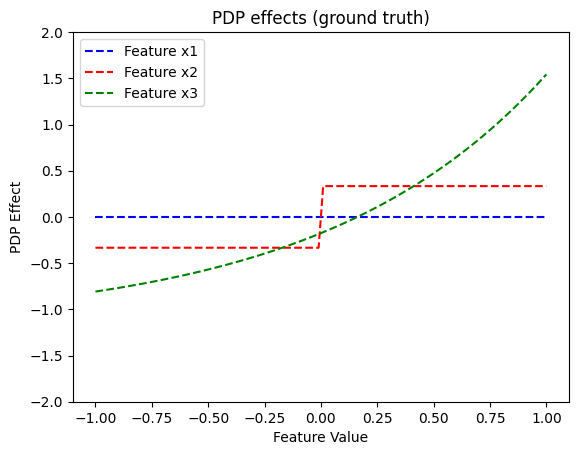

In [4]:
xx = np.linspace(-1, 1, 100)
y_pdp = []
for feature in [0, 1, 2]:
    y_pdp.append(pdp_ground_truth(feature, xx))

plt.figure()
plt.title("PDP effects (ground truth)")
color_pallette = ["blue", "red", "green"]
feature_labels = ["Feature x1", "Feature x2", "Feature x3"]
for feature in [0, 1, 2]:
    plt.plot(
        xx, 
        y_pdp[feature], 
        color=color_pallette[feature], 
        linestyle="--",
        label=feature_labels[feature],
    )
plt.legend()
plt.xlim([-1.1, 1.1])
plt.ylim([-2, 2])
plt.xlabel("Feature Value")
plt.ylabel("PDP Effect")
plt.show()


In [5]:
# make a test
xx = np.linspace(-1, 1, 100)
for feature in [0, 1, 2]:
    y_pdp = pdp.eval(feature=feature, xs=xx, centering=True)
    y_gt = pdp_ground_truth(feature, xx)
    np.testing.assert_allclose(y_pdp, y_gt, atol=1e-1)

### Conclusions

Are the PDP effects intuitive?

* For $x_1$ the effect is zero. The terms related to $x_1$ are $-x_1^2 \mathbb{1}_{x_2 <0}$ and $x_1^2 \mathbb{1}_{x_2 \geq 0}$. Both terms involve an interaction with $x_2$. Since $x_2 \sim \mathcal{U}(-1,1)$, almost half of the instances have $x_2^i < 0$ and the the other half $x_2^i \geq 0$, so the the two terms cancel out.
* For $x_2$, the effect is constant when $x_2 < 0$ or $x_2>0$ but has a positive jump of $\frac{2}{3}$ when moving from $x_2^-$ to $x_2^+$. It makes sense; when $x_2 < 0$ the active term is $-(x_1^i)^2 \mathbb{1}_{x_2 < 0} $ which adds a negative quantity to the output and when $x_2 \geq 0$ the active term is $(x_1^i)^2 \mathbb{1}_{x_2 \geq 0}$ that adds something postive. Therefore in the transmission we observe a non-linearity.
* For $x_3$, the effect is  $e^{x_3}$, as expected, since only the this term corresponds to $x_3$ and has no interaction with other variables.

### Feature importance and one-click explanation (new API)

Beyond plotting each effect, `effector` can summarize *how much* each feature
matters and produce a single auto-explanation:

- `fx.importances()` returns a per-feature importance = the dispersion of the
  mean effect (the $\mu$-twin of heterogeneity). Here $x_2$ (the jump) and
  $x_3$ (the $e^{x_3}$ curve) should rank above the flat-on-average $x_1$.
- `effector.explain(...)` runs the whole pipeline and returns a serializable
  `Report` with a self-contained HTML view.

In [6]:
# per-feature importance = dispersion of the mean effect (mu-twin of heterogeneity)
print("importances:", np.round(pdp.importances(), 3))

# one-click auto-explanation -> Report (serializable; self-contained HTML)
report = effector.explain(x, model.predict, method="pdp", nof_instances="all")
report.show()

# the whole notebook, in one page: the report published with this example
from pathlib import Path
_out = Path("reports") / "05_conditional_interaction_independent_uniform_global"
_out.mkdir(parents=True, exist_ok=True)
report.to_html(_out / "report_pdp.html")


importances: [0.007 0.326 0.668]
[effector] global effects   (GAM)  -> 86.7% of the model's variance
           regional effects (CALM) -> 99.8%

  ════════════════════════════════════════════════════════════════════════
  PDP report  ·  target: y
  ════════════════════════════════════════════════════════════════════════

  DATA & MODEL
  ────────────────────────────────────────────────────────────────────────
    instances     1,000
    features      3  ·  3 continuous
    model output  mean 1.17 · std 0.803 · range [-0.546, 3.38]

  EXPLAINED VARIANCE
  ────────────────────────────────────────────────────────────────────────
    step         split on                 solo     ΔR²      R²       heter
    ──────────────────────────────────────────────────────────────────────
    GAM          (all features global)       —       —   86.7%           —
  + x_0          x_1                    +13.1%  +13.1%   99.8% 0.29 → 0.00
    ─────────────────────────────────────────────────────────────

/home/givasile/github/packages/effector/effector/report.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


## ALE

### Effector

Let's see below the PDP effects for each feature, using `effector`.

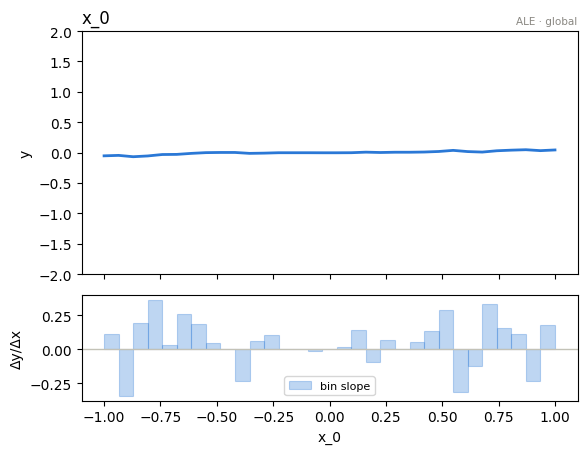

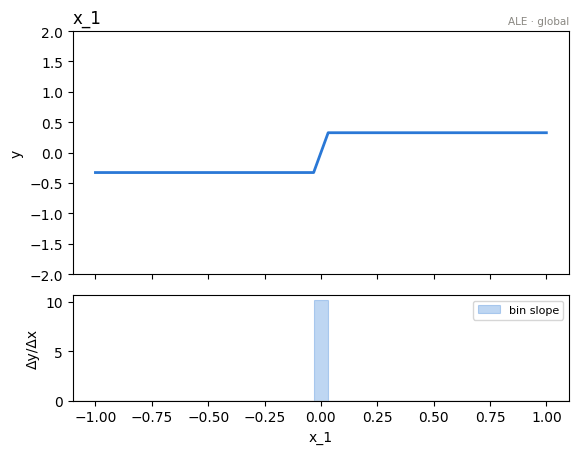

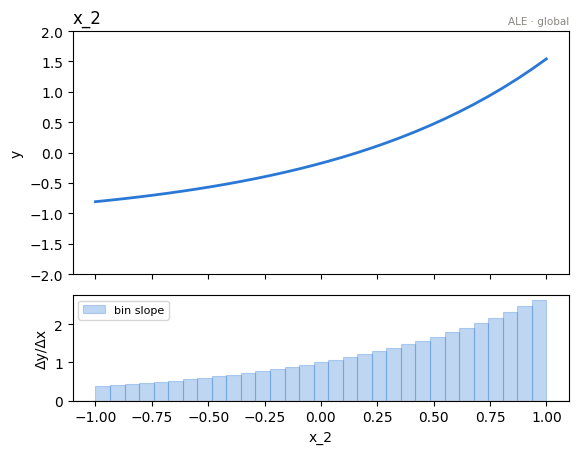

In [7]:
ale = effector.ALE(x, model.predict, axis_limits=dataset.axis_limits)
ale.fit(features="all", centering=True, binning_method=effector.axis_partitioning.Fixed(nof_bins=31))

for feature in [0, 1, 2]:
    ale.plot(feature=feature, centering=True, y_limits=[-2, 2], heterogeneity=False)

ALE states that:
- $x_1$ has a zero average effect on the model output (same as PDP)
- $x_2$ has a constant effect when $x_2 <0$ or $x_2 >0$, but when moving from $x_2^-$ to $x_2^+$ it adds (on average) $+\frac{2}{3}$ units to $y$ (same as PDP)
- $x_3$ has an effect of $e^{x_3}$ (same as PDP)


### Derivations

\begin{align}
ALE(x_1) &\propto \sum_{k=1}^{k_{x_1}} \frac{1}{| \mathcal{S}_k |} \sum_{i: x^i \in \mathcal{S}_k} \left [  f(z_k, x^i_2, x^i_3) - f(z_{k-1}, x^i_2, x^i_3) \right ] \\
&\propto \sum_{k=1}^{k_{x_1}} \frac{1}{| \mathcal{S}_k |} \sum_{i: x^{(i)} \in \mathcal{S}_k} \left [ -z_k^2 \mathbb{1}_{x_2^i <0} + z_k^2 \mathbb{1}_{x_2^i \geq 0} + e^{x_3^i} - (-z_{k-1}^2 \mathbb{1}_{x_2^i <0} + z_{k-1}^2 \mathbb{1}_{x_2^i \geq 0} + e^{x_3^i} ) \right ] \\
&\propto \sum_{k=1}^{k_{x_1}} \frac{1}{| \mathcal{S}_k |} \sum_{i: x^{(i)} \in \mathcal{S}_k} \left [ -z_k^2 \underbrace{(\mathbb{1}_{x_2^i <0} - \mathbb{1}_{x_2^i \geq 0})}_{\approx 0} + z_{k-1}^2 \underbrace{(\mathbb{1}_{x_2^i <0} - \mathbb{1}_{x_2^i \geq 0})}_{\approx 0} \right ] \\
&\approx \sum_{k=1}^{k_{x_1}} \frac{1}{| \mathcal{S}_k |} \sum_{i: x^{(i)} \in \mathcal{S}_k} 0 \\
&\approx 0
\end{align}

\begin{align}
ALE(x_2) &\propto \sum_{k=1}^{k_{x_2}} \frac{1}{| \mathcal{S}_k |} \sum_{i: x^{(i)} \in \mathcal{S}_k} \left [  f(x_i^1, z_k, x^i_3) - f(x_i^1, z_{k-1}, x^i_3 \right ] \\
&\propto \sum_{k=1}^{k_{x_2}} \frac{1}{| \mathcal{S}_k |} \sum_{i: x^{(i)} \in \mathcal{S}_k} \left [ -(x^i_1)^2 \mathbb{1}_{z_k <0} + (x^i_1)^2 \mathbb{1}_{z_k \geq 0} - (-(x^i_1)^2 \mathbb{1}_{z_{k-1} <0} + (x^i_1)^2 \mathbb{1}_{z_{k-1} \geq 0}) \right ] \\
\end{align}

For all bins, except the central, it holds that bin limits are either both negative or both positive, so the effects cancel out.
For central bin, i.e., the one from $-\frac{2}{K}$ to $\frac{2}{K}$, the effect is $\frac{(2x^i_1)^2}{| \mathcal{S}_k |} = \frac{2}{3} \frac{K}{2} = \frac{K}{3}$.
Therefore, the ALE effect is:

\begin{equation}
ALE(x_2) \approx
\begin{cases}
-\frac{1}{3} \text{ if } x_2 < -\frac{2}{K} \\
\frac{1}{3} \text{ if } x_2 > \frac{2}{K} \\
\text{a linear segment from $-\frac{1}{3}$ to $\frac{1}{3}$ in between}
\end{cases} \\
\end{equation}



\begin{align}
ALE(x_3) &\propto \sum_{k=1}^{k_{x_3}} \frac{1}{| \mathcal{S}_k |} \sum_{i: x^{(i)} \in \mathcal{S}_k} \left [  f(x^i_1, x^i_2, z_k) - f(x^i_1, x^i_2, z_{k-1}) \right ] \\
&\propto \sum_{k=1}^{k_{x_3}} \frac{1}{| \mathcal{S}_k |} \sum_{i: x^{(i)} \in \mathcal{S}_k} \left [ e^{z_k} - e^{z_{k-1}} \right ] \\
&\approx e^{x_3}
\end{align}

### Tests

In [8]:
# The closed form below lives in `effector.benchmarks` — the SAME function the
# test suite asserts against (tests/test_functional_conditional_interaction.py),
# so this notebook and the tests can never disagree about the right answer.
ale_ground_truth = bench.ale_gt

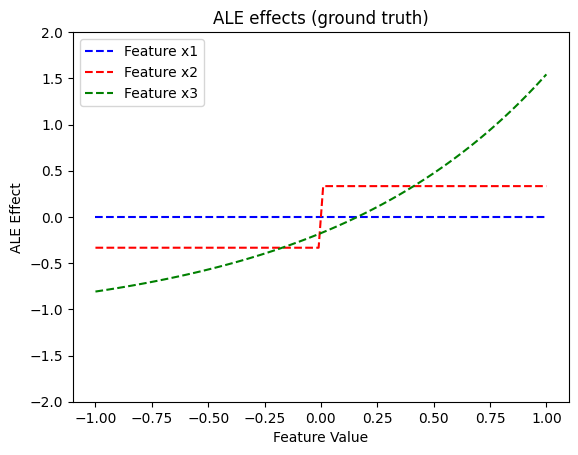

In [9]:
xx = np.linspace(-1, 1, 100)
y_ale = []
for feature in [0, 1, 2]:
    y_ale.append(ale_ground_truth(feature, xx))
    
plt.figure()
plt.title("ALE effects (ground truth)")
color_pallette = ["blue", "red", "green"]
feature_labels = ["Feature x1", "Feature x2", "Feature x3"]
for feature in [0, 1, 2]:
    plt.plot(
        xx, 
        y_ale[feature], 
        color=color_pallette[feature], 
        linestyle="--",
        label=feature_labels[feature]
    )
plt.legend()
plt.xlim([-1.1, 1.1])
plt.ylim([-2, 2])
plt.xlabel("Feature Value")
plt.ylabel("ALE Effect")
plt.show()
    

In [10]:
xx = np.linspace(-1, 1, 100)
for feature in [0, 1, 2]:
    y_ale = ale.eval(feature=feature, xs=xx, centering=True)
    y_gt = ale_ground_truth(feature, xx)
    
    # hack to remove the effect at undefined region
    if feature == 1:
        K = 31
        ind = np.logical_and(xx > -1/K, xx < 1/K)
        y_ale[ind] = 0
        y_gt[ind] = 0
    
    np.testing.assert_allclose(y_ale, y_gt, atol=1e-1)
    

### Conclusions

Are the ALE effects intuitive?

ALE effects are identical to PDP effects which, as discussed above, can be considered intutive.

## RHALE

### Effector

Let's see below the RHALE effects for each feature, using `effector`.

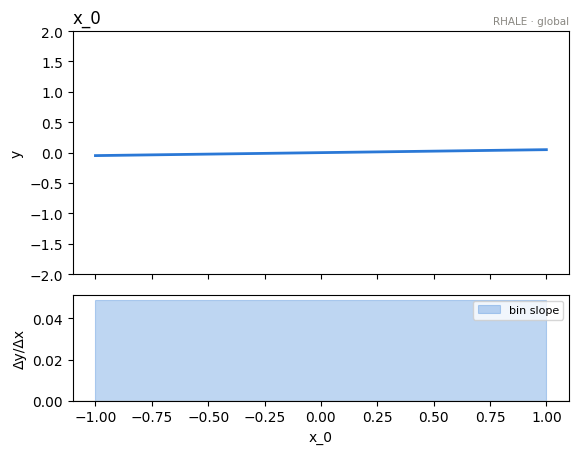

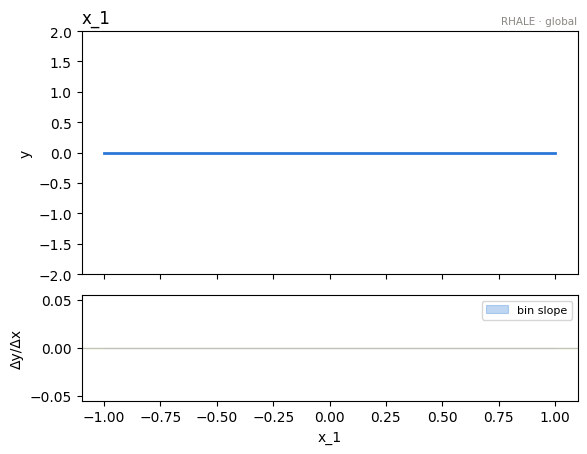

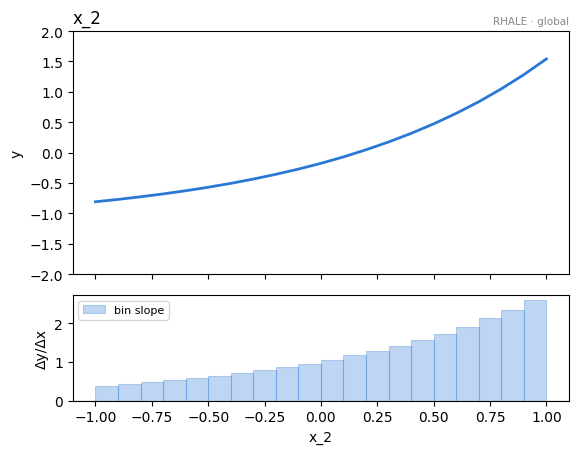

In [11]:
rhale = effector.RHALE(x, model.predict, model.jacobian, axis_limits=dataset.axis_limits)
rhale.fit(features="all", centering=True)

for feature in [0, 1, 2]:
    rhale.plot(feature=feature, centering=True, y_limits=[-2, 2], heterogeneity=False)

RHALE states that:
- $x_1$ has a zero average effect on the model output (same as PDP)
- $x_2$ has a zero average effect on the model output (different than PDP and ALE)
- $x_3$ has an effect of $e^{x_3}$ (same as PDP)


### Derivations

\begin{align}
RHALE(x_1) &\propto \sum_{k=1}^{k_{x_1}} \frac{1}{| \mathcal{S}_k |} (z_k - z_{k-1}) \sum_{i: x^i \in \mathcal{S}_k} \left [  \frac{\partial f}{\partial x_1}(\mathbf{x}^i) \right ] \\
&\propto \sum_{k=1}^{k_{x_1}} \frac{1}{| \mathcal{S}_k |} (z_k - z_{k-1}) \sum_{i: x^{(i)} \in \mathcal{S}_k} \left [ -2x_1 \mathbb{1}_{x_2^i <0} + 2x_1 \mathbb{1}_{x_2^i \geq 0}  \right ] \\
&\propto \sum_{k=1}^{k_{x_1}} \frac{1}{| \mathcal{S}_k |} (z_k - z_{k-1}) \sum_{i: x^{(i)} \in \mathcal{S}_k} \left [ -2x_1 \underbrace{(\mathbb{1}_{x_2^i <0} - \mathbb{1}_{x_2^i \geq 0})}_{\approx 0} \right ] \\
&\approx \sum_{k=1}^{k_{x_1}} \frac{1}{| \mathcal{S}_k |} \sum_{i: x^{(i)} \in \mathcal{S}_k} 0 \\
&\approx 0
\end{align}

\begin{align}
RHALE(x_2) &\propto \sum_{k=1}^{k_{x_2}} \frac{1}{| \mathcal{S}_k |} (z_k - z_{k-1}) \sum_{i: x^i \in \mathcal{S}_k} \left [  \frac{\partial f}{\partial x_2}(\mathbf{x}^i) \right ] \\
&\propto \sum_{k=1}^{k_{x_2}} \frac{1}{| \mathcal{S}_k |} (z_k - z_{k-1}) \sum_{i: x^i \in \mathcal{S}_k} 
\begin{cases}
0 & \text{if } x_2 < 0 \\
0 & \text{if } x_2 \geq 0
\end{cases} \\
&\propto 0
\end{align}

\begin{align}
RHALE(x_3) &\propto \sum_{k=1}^{k_{x_3}} \frac{1}{| \mathcal{S}_k |} (z_k - z_{k-1}) \sum_{i: x^i \in \mathcal{S}_k} \left [  \frac{\partial f}{\partial x_3}(\mathbf{x}^i) \right ] \\
&\propto \sum_{k=1}^{k_{x_3}} \frac{1}{| \mathcal{S}_k |} (z_k - z_{k-1}) \sum_{i: x^i \in \mathcal{S}_k} \left [ e^{x_3} \right ] \\
&\approx e^{x_3}
\end{align}

### Tests

In [12]:
# The closed form below lives in `effector.benchmarks` — the SAME function the
# test suite asserts against (tests/test_functional_conditional_interaction.py),
# so this notebook and the tests can never disagree about the right answer.
rhale_ground_truth = bench.rhale_gt

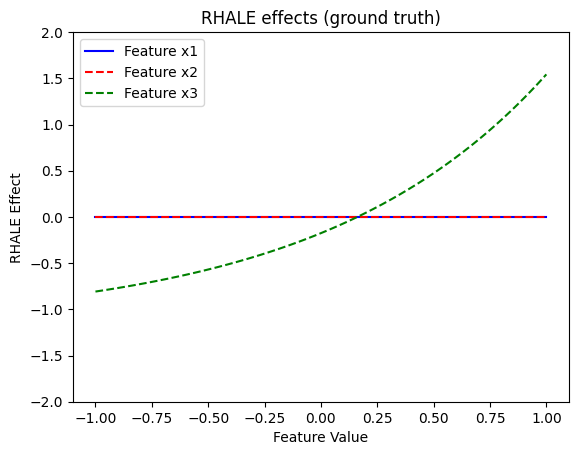

In [13]:
xx = np.linspace(-1, 1, 100)
y_rhale = []
for feature in [0, 1, 2]:
    y_rhale.append(rhale_ground_truth(feature, xx))
    
plt.figure()
plt.title("RHALE effects (ground truth)")
color_pallette = ["blue", "red", "green"]
feature_labels = ["Feature x1", "Feature x2", "Feature x3"]
for feature in [0, 1, 2]:
    plt.plot(
        xx, 
        y_rhale[feature], 
        color=color_pallette[feature], 
        linestyle="-" if feature == 0 else "--",
        label=feature_labels[feature]
    )
plt.legend()
plt.xlim([-1.1, 1.1])
plt.ylim([-2, 2])
plt.xlabel("Feature Value")
plt.ylabel("RHALE Effect")
plt.show()



In [14]:
for feature in [0, 1, 2]:
    y_ale = rhale.eval(feature=feature, xs=xx, centering=True)
    y_gt = rhale_ground_truth(feature, xx)
    np.testing.assert_allclose(y_ale, y_gt, atol=1e-1)

### Conclusions

Are the RHALE effects intuitive?

RHALE does not add something new, compared to ALE and PDP, for features $x_1$ and $x_3$. 
For $x_2$, however, it does not capture the abrupt increase by $+\frac{2}{3}$ units when moving from $x_2^-$ to $x_2^+$, which can be considered as an error mode of RHALE. In fact, RHALE requires a differentiable black box model, and since $f$ is not differentiable with respect to $x_2$, that is why we get a slightly misleading result.

## Cross-method sanity check

The one-liner `effector.explain` with every engine this notebook's model
supports. Everything must run end to end; the closing table puts the reads
side by side. Where methods disagree — ranking, accepted splits, R² — that is
a property of the data/model worth a closer look, not an error.


In [15]:
from pathlib import Path
_out = Path("reports") / "05_conditional_interaction_independent_uniform_global"
_out.mkdir(parents=True, exist_ok=True)

# === cross-method sweep: effector.explain on every applicable engine ======
sweep_reports = {}
for _m in ["pdp", "derpdp", "ale", "rhale", "shapdp"]:
    _kw = {"nof_instances": 300} if _m == "shapdp" else {}
    print(f"--- {_m} " + "-" * 50)
    sweep_reports[_m] = effector.explain(
        x, model.predict, model.jacobian, method=_m, **_kw
    )
    if _m != "pdp":  # the published report is the narrated one above
        sweep_reports[_m].to_html(_out / f"report_{_m}.html")

print()
print(f"{'method':<8} {'ranking (plotted)':<44} {'GAM R2':>8} {'final R2':>9}  splits")
for _m, _r in sweep_reports.items():
    _rank = " > ".join(fr.name for fr in _r.features)
    _ev = _r.explained_variance
    if _ev:
        _sp = "; ".join(f"{s['name']} on {s['on']}" for s in _ev["stages"]) or "none"
        print(f"{_m:<8} {_rank:<44} {_ev['gam_r2']:>7.1%} {_ev['regional_r2']:>8.1%}  {_sp}")
    else:
        print(f"{_m:<8} {_rank:<44} {'-':>7} {'-':>8}  (derivative scale: no variance ledger)")

print(f"\nreports stored in {_out}/")


--- pdp --------------------------------------------------
[effector] global effects   (GAM)  -> 86.7% of the model's variance
           regional effects (CALM) -> 99.8%
--- derpdp --------------------------------------------------


/home/givasile/github/packages/effector/effector/report.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- ale --------------------------------------------------
[effector] global effects   (GAM)  -> 85.3% of the model's variance
           regional effects (CALM) -> 98.8%


/home/givasile/github/packages/effector/effector/report.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- rhale --------------------------------------------------
[effector] global effects   (GAM)  -> 70.0% of the model's variance
           regional effects (CALM) -> 100.0%


/home/givasile/github/packages/effector/effector/report.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- shapdp --------------------------------------------------


[effector] global effects   (GAM)  -> 87.3% of the model's variance
           regional effects (CALM) -> 96.6%


/home/givasile/github/packages/effector/effector/report.py:606: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()



method   ranking (plotted)                              GAM R2  final R2  splits
pdp      x_2 > x_1 > x_0                                86.7%    99.8%  x_0 on x_1
derpdp   x_2                                                -        -  (derivative scale: no variance ledger)
ale      x_2 > x_1 > x_0                                85.3%    98.8%  x_0 on x_1
rhale    x_2 > x_0                                      70.0%   100.0%  x_0 on x_1
shapdp   x_2 > x_1 > x_0                                87.3%    96.6%  x_0 on x_1

reports stored in reports/05_conditional_interaction_independent_uniform_global/
